# Project 1 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the MNIST data set. 

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

## Introduction

The first time when looking at a csv dataset, it can be benefical to load it in using pandas, to get a sense of the datas content.

Shape images (before): (10000, 784)
Shape labels (before): (10000, 1)
Shape images (after): (2000, 784)
Shape labels (after): (2000, 1)


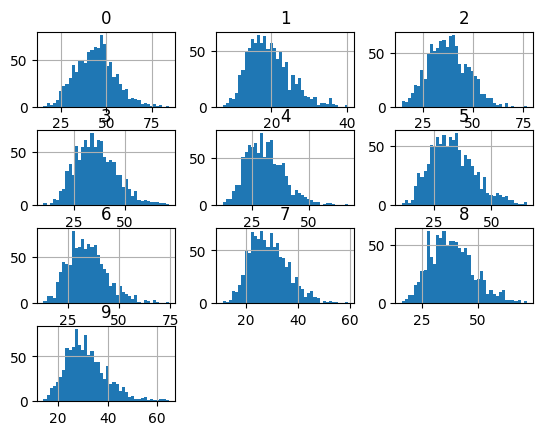

In [4]:
# To run this notebook yourself, the data needs to be unzipped and 
# the path variable specified to point to the unzipped data folder.
# Here we place it in the same folder as the zipped data.

import pandas as pd

PATHIM = "mnist_large//images.csv"
PATHLB = "mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

print(f"Shape images (before): {images.shape}")
print(f"Shape labels (before): {labels.shape}")

# To sort by a specific label:
mask = labels["label"].isin([0,9])

images_0_9 = images.loc[mask].copy()
labels_0_9 = labels.loc[mask].copy()

print(f"Shape images (after): {images_0_9.shape}")
print(f"Shape labels (after): {labels_0_9.shape}")

# To check the class labels:
labels["label"].value_counts()

# Compare histograms for pixel intensity betwen classes
df = images.join(labels) 
df["mean_intensity"] = images.mean(axis=1)

df.pivot(columns="label", values="mean_intensity").hist(bins=40);

For dealing with images, which are not particularly well suited in tabular formats, numpy is a better tool

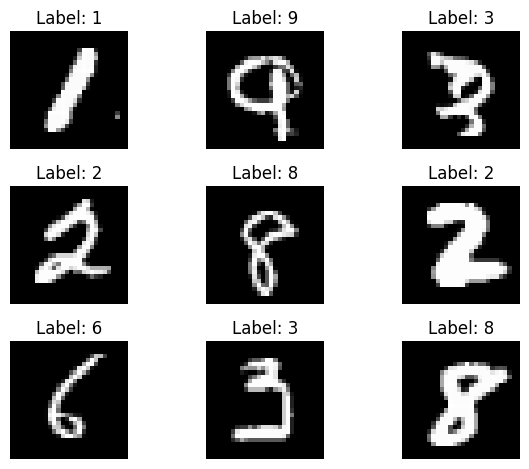

In [3]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]
n_samples = 9

idx = np.random.choice(n_images, size = n_samples, replace = False)
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(3, 3)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

Digit = 1 | Train (n): 150, Test (n): 50, Train (%): 0.75
Digit = 5 | Train (n): 150, Test (n): 50, Train (%): 0.75
Digit = 7 | Train (n): 150, Test (n): 50, Train (%): 0.75


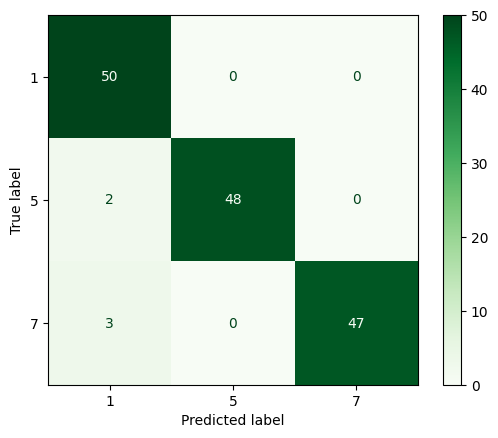

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Subet on three classes (NOTE: We are now doing the susbetting in numpy and not pandas)
digits = [1, 5, 7]
mask = (labels == digits[0]) | (labels == digits[1]) | (labels == digits[2]) 
images_sub = images[mask]
labels_sub = labels[mask]

# Create a test and train set
x_train, x_test, y_train, y_test = train_test_split(images_sub, labels_sub, test_size=0.25, stratify=labels_sub)

# Sanity check
for digit in digits:
    train_digits = np.sum(y_train == digit)
    test_digits = np.sum(y_test == digit)
    prop = train_digits / (train_digits + test_digits)
    print(f"Digit = {digit} | Train (n): {train_digits}, Test (n): {test_digits}, Train (%): {prop}")


# Apply to train
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(x_train, y_train)

# Predict on test data
preds = neigh.predict(x_test)

cm = confusion_matrix(y_test, preds, labels=digits)
ConfusionMatrixDisplay(cm, display_labels=digits).plot(cmap='Greens')



# Part 1

*Everyone should do this task.*

The purpose of this first exercise is to build a classification pipeline, from data exploration to validation. Remember to split your data into appropriate sets before you start.
You should explore at least 4 *different* classifiers of *different* character.

1. Perform dimension reduction on the data set. Is the data well separated?
2. Train the classifiers using the training data, and perform cross-validation to tune the models that require tuning.
3. Compare the performance of the different classifiers on a test set.

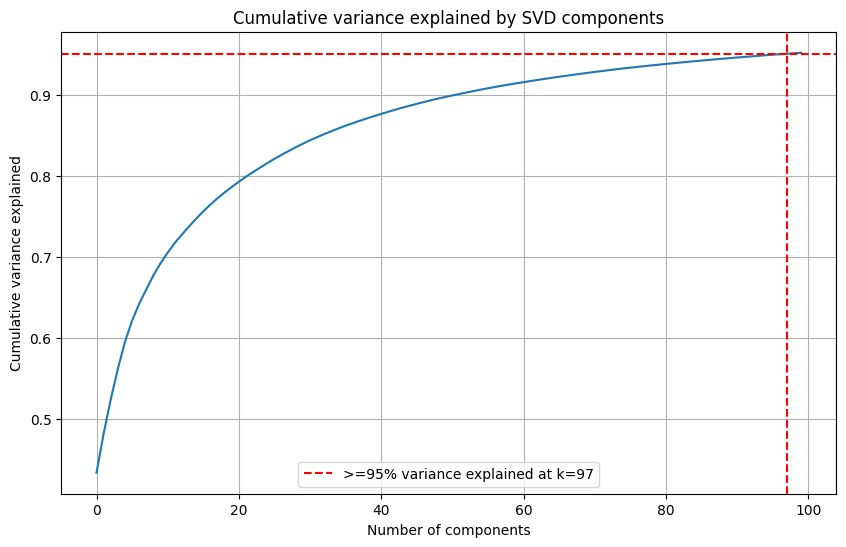

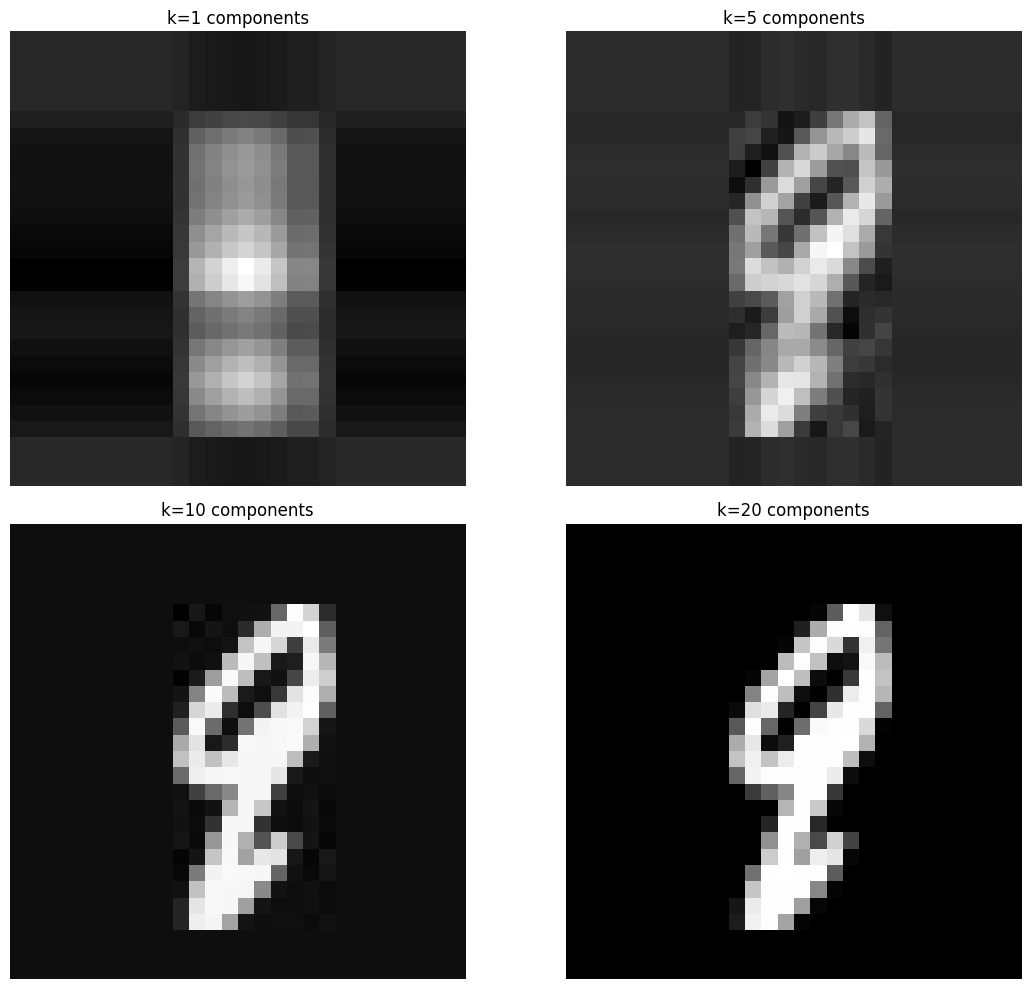

In [47]:
#Visualisations
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import urllib.request
import gzip
import io
from matplotlib import colormaps

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

color_map = plt.cm.tab10

images = np.array(images)
labels = np.array(labels).ravel()




X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

n_images = X_train.shape[0]
n_samples = 9

#Get 2000 random digits
np.random.seed(1000)
sample_idx = np.random.choice(n_images, 2000, replace=False)
X_sample = X_train[sample_idx]
y_sample = y_train[sample_idx]

#Compute SVD (looks at different things and how much they matter basically)
U, S, vt = np.linalg.svd(X_sample, full_matrices = False)
#Breaks the matrix into three simpler matrices, U, S, and vt. X=USV^T. 
#U is basically important patterns in the sample
#S is basically how important each pattern is (big numers-> more important)
#Vt main feature direction. Ie which combination of columns that matter most.


#Calculates the cummulative variance explained by the different patterns
var_explained = np.cumsum(S**2) / np.sum(S**2)

#Find the first k that explain >=95% of variance
for i, var in enumerate(var_explained):
    if var >= 0.95:
        indx_95 = i
        var_95 = var
        break

#Graphs the cummulative variance and shows the first k that expalined >=95%
plt.figure(figsize=(10, 6))
plt.plot(var_explained[:100])
plt.axhline(y=var_95, color='r', linestyle='--', label=f'>=95% variance explained at k={indx_95}')
plt.axvline(x=indx_95, color='r', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
plt.title('Cumulative variance explained by SVD components')
plt.grid(True)
plt.legend()
plt.show()



#Looks at a singular test_image
test_image = X_sample[5].astype(np.float64)
test_image = test_image.reshape(28, 28)  # Reshape to 28x28 for visualization

fig, axes = plt.subplots(2,2, figsize=(12, 10))

U_one, S_one, vt_one = np.linalg.svd(test_image - np.mean(test_image), full_matrices = False)
#Tests different k values for this test image and show the results we get
for i, k in enumerate([1, 5, 10, 20]):
    ax = axes.flat[i]
    #Reconstrust the image looking only at the first k components
    recon = U_one[:, :k] @ np.diag(S_one[:k]) @ vt_one[:k, :] + np.mean(test_image)
    ax.imshow(recon, cmap='gray')
    ax.set_title(f'k={k} components')
    ax.axis('off')
plt.tight_layout()
plt.show()
"""


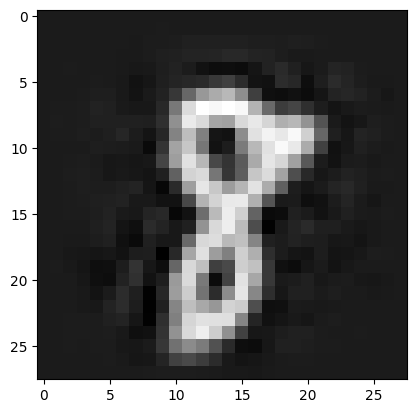

In [45]:
#Get only the k first thingys
"""
X_recon = U[:, :indx_95] @ np.diag(S[:indx_95]) @ vt[:indx_95, :]

plt.imshow(X_recon[0].reshape(28, 28), cmap='gray')
"""

In [ ]:
#split the data

#Is the data well seperated?

In [52]:
#Split data into test and train
np.random.seed(42)
n = len(images)
train_idx = np.random.choice(n, 2000, replace=False)
test_idx = np.array([i for i in range(n) if i not in train_idx])

X_train_org = images[train_idx]
y_train = labels[train_idx]
X_test_org = images[test_idx]
y_test = labels[test_idx]


In [54]:
#Do SVD on training data
U_train, S_train, vt_train = np.linalg.svd(X_train_org, full_matrices = False)


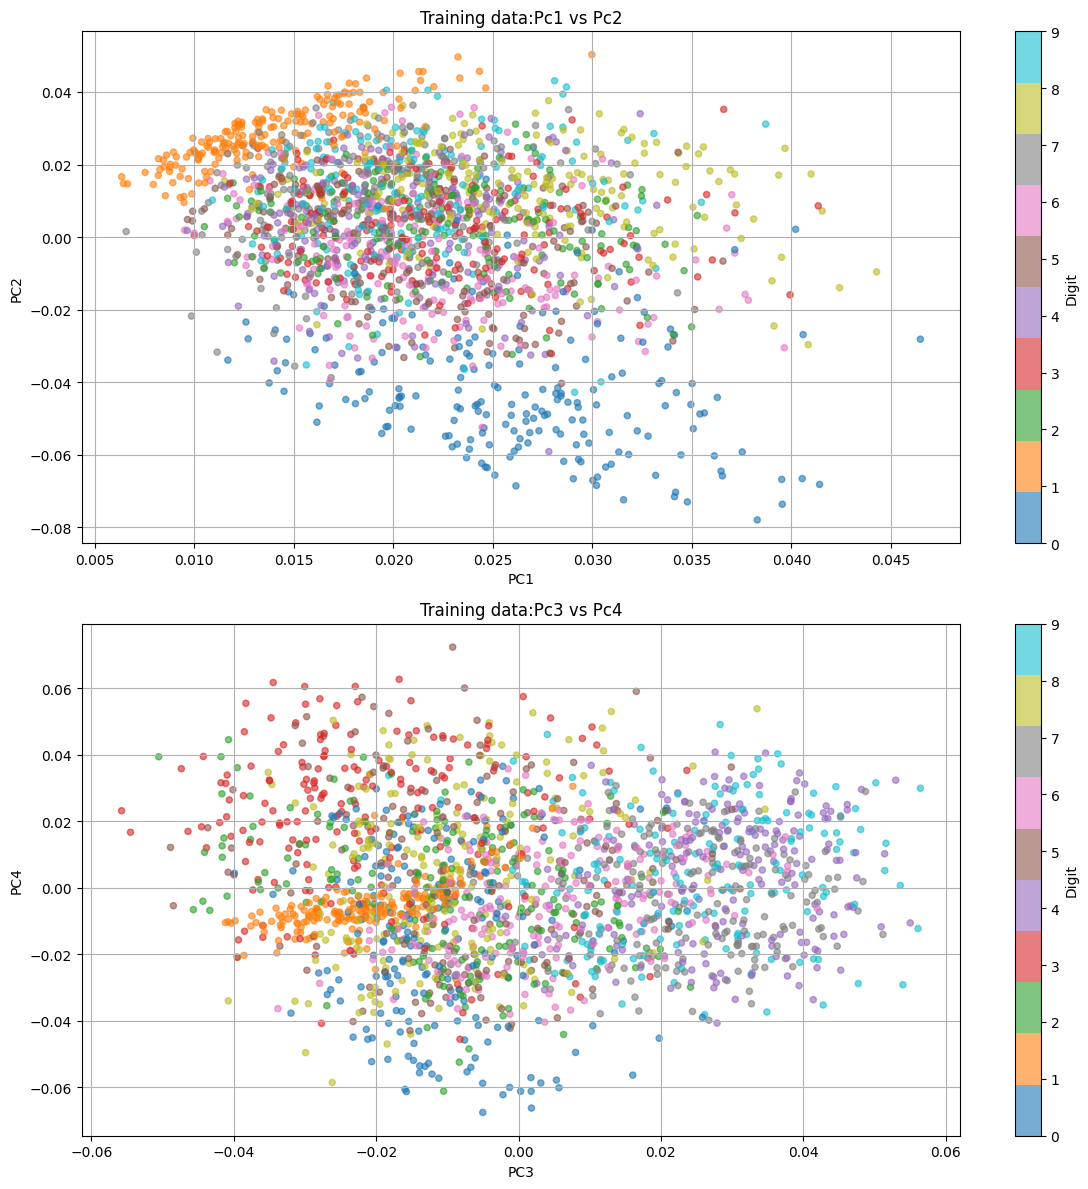

In [ ]:
#Is the training data well seperated?
fig, ax = plt.subplots(2,1, figsize=(12, 12))
scatter = ax[0].scatter(U_train[:, 0], U_train[:, 1], c=y_train, cmap = 'tab10', s=20, alpha = 0.6)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_title('Training data:Pc1 vs Pc2')
plt.colorbar(scatter, label = 'Digit')
ax[0].grid(True)

scatter_2 = ax[1].scatter(U_train[:, 2], U_train[:, 3], c=y_train, cmap = 'tab10', s=20, alpha = 0.6)
ax[1].set_xlabel('PC3')
ax[1].set_ylabel('PC4')
ax[1].set_title('Training data:Pc3 vs Pc4')
plt.colorbar(scatter_2, label = 'Digit')
ax[1].grid(True)

plt.tight_layout()
plt.show()

#Some of them are well seperated (like 1 and 0), but most of them are not. We can see that the first 4 PCs are not enough to well seperate the data. We will need more patterns to do that.


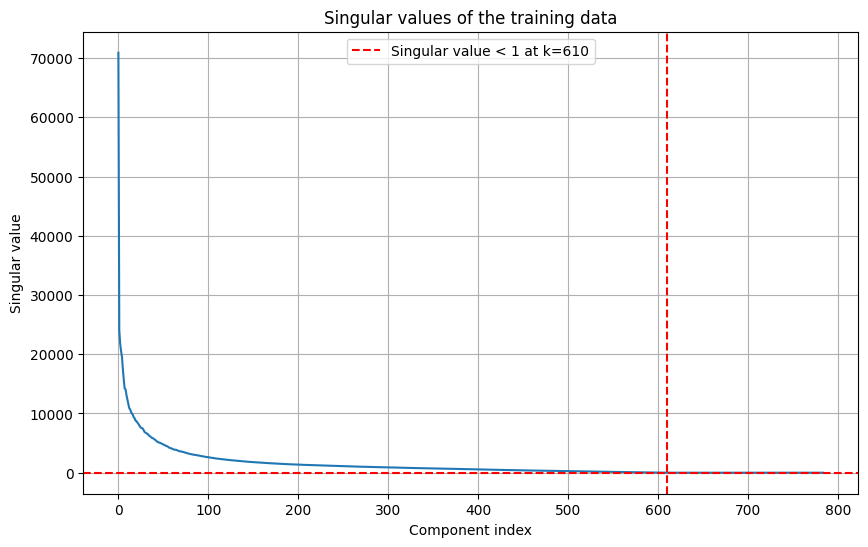

In [53]:
"""

#Typical selection rule to look at about how many patterns are relevant:
for i, d in enumerate(S_train):
    if d < 1:
        indx_1 = i
        d_1 = d
        break

plt.figure(figsize=(10, 6))
plt.plot(S_train[:1000])
plt.axhline(y=d_1, color='r', linestyle='--', label=f'Singular value < 1 at k={indx_1}')
plt.axvline(x=indx_1, color='r', linestyle='--')
plt.xlabel('Component index')
plt.ylabel('Singular value')
plt.title('Singular values of the training data')
plt.grid(True)
plt.legend()
plt.show()
"""


In [153]:
from matplotlib.patches import Patch
#General functions
#Function to calculate the new x_train and x_test with fewer patterns
def calc_reduced_pattern(U, S, vt, p_val, X_test_org, X_val_org):
    #Projected data:
    X_train_proj = U[:, :p_val] @ np.diag(S[:p_val])
    x_test_proj = X_test_org @ vt[:p_val, :].T
    x_val_proj = X_val_org @ vt[:p_val, :].T
    return X_train_proj, x_test_proj, x_val_proj

#Visualisation of how "wrong" the data is:
def visuale_error(x_axs, y_axs, x_name, y_name, title, results_val, ord_x, ord_y):
    #fig, ax = plt.subplots(1,2, figsize=(12, 6))

    #Effect of K
    colours = plt.cm.Set3(np.linspace(0, 1, len(x_axs)))
    bp_list = []

    for i, x_val in enumerate(x_axs):
        mask = results_val[:,ord_x] == x_val

        err_list = [results_val[mask, 2]] #Wrap in list
        pos = np.arange(len(y_axs)) + i*0.12 #Create single-value boxplots at multiple different positions


        for j, y_val in enumerate(y_axs):
            mask_y = (results_val[:,ord_x] == x_val) & (results_val[:,ord_y] == y_val)

            err_list_y = results_val[mask_y, 2]
            bp = plt.boxplot(err_list_y, positions=[pos[j]], widths = 0.1, patch_artist= True, boxprops = dict(facecolor=colours[i], alpha=0.7))


    plt.xlabel(y_name)
    plt.title(f'{title} error rate for different {x_name} and different {y_name}')
    plt.xticks(np.arange(len(y_axs))+0.5, [y_ax for y_ax in y_axs])
    plt.ylabel("Error rate")
    plt.grid(True, alpha = 0.3, axis = 'x')
    legend_elements = [Patch(facecolor = colours[i], alpha =0.7, label = f'{x_name} = {x_axs[i]}') for i in range(len(x_axs))]
    plt.legend(handles = legend_elements, loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()



def visuale_error_for_one(x_axs, x_name, title, results_val, ord_x):
    #fig, ax = plt.subplots(1,2, figsize=(12, 6))


    for i, x_val in enumerate(x_axs):
        mask = results_val[:,ord_x] == x_val

        err_list = [results_val[mask, 1]] #Wrap in list
        pos = np.arange(len(x_axs)) + i*0.12 #Create single-value boxplots at multiple different positions


        bp = plt.boxplot(err_list, positions=[pos[i]], widths = 0.1, patch_artist= True)


    plt.xlabel(x_name)
    plt.title(f'{title} error rate for different {x_name}')
    plt.xticks(np.arange(len(x_axs))+0.5, [x_ax for x_ax in x_axs])

    plt.ylabel("Error rate")
    plt.grid(True, alpha = 0.3, axis = 'x')
    plt.tight_layout()
    plt.show()


def compute_SVD(X, y, n):
    train_idx = np.random.choice(n, 2000, replace=False)
    remaining = np.array([i for i in range(n) if i not in train_idx])
    val_idx = np.random.choice(remaining, 2000, replace=False)
    test_idx = np.array([i for i in remaining if i not in val_idx])

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_val = X[val_idx]
    y_val = y[val_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]

    X_mean = np.mean(X_train, axis=0)
    X_train_centered = X_train - X_mean

    U_train, S_train, vt_train = np.linalg.svd(X_train_centered, full_matrices = False)

    return X_train, y_train, (X_val - X_mean), y_val, (X_test-X_mean), y_test, U_train, S_train, vt_train



In [161]:
from sklearn.neighbors import KNeighborsClassifier
import os

k_vals = [1,2,5,10,25,50]
P_vals = [2,3,10, 25, 50, 100, 150, 200]
B = 25 # num of splits

results_val = []
results_test = []

for b in range(B):
    print(f"b is {b}")
    x_train, y_train, x_val, y_val, x_test, y_test, U_train, S_train, vt_train = compute_SVD(images, labels, images.shape[0])
    for pp, p_val in enumerate(P_vals):
        x_train_proj, x_test_proj, x_val_proj = calc_reduced_pattern(U_train, S_train, vt_train, p_val, x_test, x_val)

        for kk, k_val in enumerate(k_vals):
            #Use skleans KNeighbours Classifier
            knn = KNeighborsClassifier(n_neighbors=k_val)
            knn.fit(x_train_proj, y_train)
            pred_val = knn.predict(x_val_proj)
            pred_test = knn.predict(x_test_proj)

            #Compute error rates
            err_val = np.sum(pred_val != y_val) / len(y_val)
            err_test = np.sum(pred_test != y_test) /len(y_test)

            results_val.append([p_val, k_val, err_val])
            results_test.append([p_val, k_val, err_test])



b is 0
b is 1
b is 2
b is 3
b is 4
b is 5
b is 6
b is 7
b is 8
b is 9
b is 10
b is 11
b is 12
b is 13
b is 14
b is 15
b is 16
b is 17
b is 18
b is 19
b is 20
b is 21
b is 22
b is 23
b is 24


(1200, 3)
25


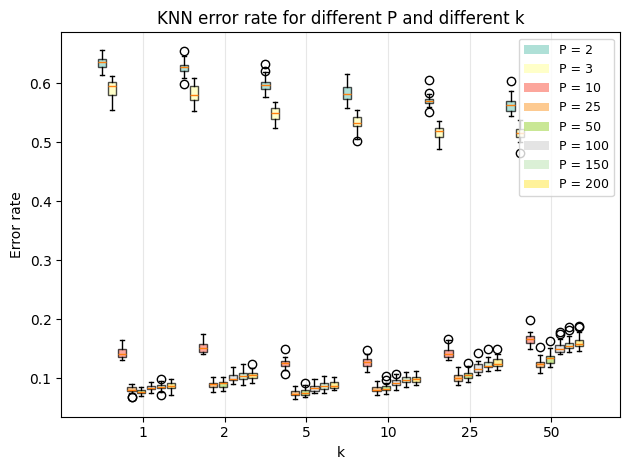

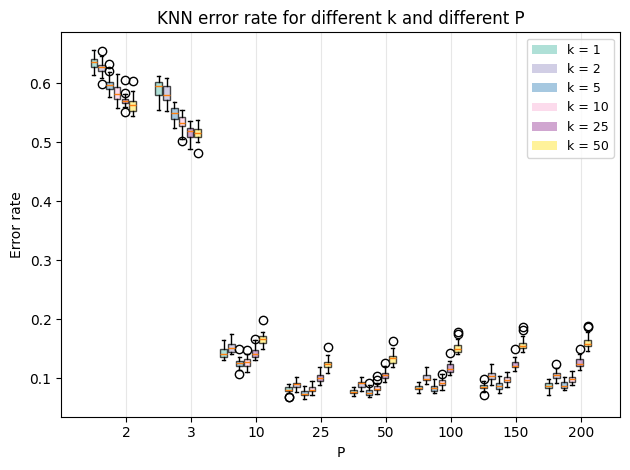

In [154]:
results_val_upd = np.array(results_val)
results_test_upd = np.array(results_test)

print(results_val_upd.shape)
print(len(results_val_upd[(results_val_upd[:,0] == 100) & (results_val_upd[:,1] == 50)]))

visuale_error(P_vals, k_vals, 'P', 'k', 'KNN', results_val_upd, 0, 1)
visuale_error(k_vals, P_vals, 'k', 'P', 'KNN', results_val_upd, 1, 0)

In [114]:
"""
errors = np.zeros((len(P_vals), len(k_vals)))
smallest_err = np.inf
best_comb = [0, 0]
errors_list = []
for i, p_val in enumerate(P_vals):
        for j, k_val in enumerate(k_vals):
            mask = (results_val_upd[:, 0] == p_val) & (results_val_upd[:, 1] == k_val)
            errors[i, j] = np.mean(results_val_upd[mask, 2]) #Take the mean error across the B splits for this combination of P and k
            if errors[i, j] < smallest_err:
                smallest_err = errors[i, j] 
                best_comb = [p_val, k_val]
                errors_list = results_test_upd[mask, 2]

#Take the best comb of k and P
k_best = best_comb[1]
P_best = best_comb[0]
best_err = np.mean(results_test_upd[(results_test_upd[:, 0] == P_best) & (results_test_upd[:, 1] == k_best), 2])
print(f"Best combination: P={P_best}, k={k_best} with error {best_err}")
"""

Best combination: P=25, k=5 with error 0.07838666666666666


In [158]:
def find_errors(x_vals, y_vals):
    errors = np.zeros((len(x_vals), len(y_vals)))
    smallest_err = np.inf
    best_comb = [0, 0]
    errors_list = []

    for i, x_val in enumerate(x_vals):
        for j, y_val in enumerate(y_vals):
            mask = (results_val_upd[:, 0] == x_val) & (results_val_upd[:, 1] == y_val)
            errors[i, j] = np.mean(results_val_upd[mask, 2]) #Take the mean error across the B splits for this combination of P and k
            if errors[i, j] < smallest_err:
                smallest_err = errors[i, j] 
                best_comb = [x_val, y_val]
                errors_list = results_test_upd[mask, 2]
    return smallest_err, best_comb, errors_list

smallest_err, best_comb, errors_list = find_errors(P_vals, k_vals)
best_err = np.mean(results_test_upd[(results_test_upd[:, 0] == best_comb[0]) & (results_test_upd[:, 1] == best_comb[1]), 2])
print(f"Best combination: P={best_comb[0]}, k={best_comb[1]} with error {best_err}")    


Best combination: P=25, k=5 with error 0.07838666666666666


In [ ]:
"""Okay, so now we have the basic idea of the concept of how to do it
Next we need to do it with several different methods (4 different classifiers of 4 different characters)"""

In [145]:
#Lets try with linear discriminant analysis (LDA) instead of KNN. 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



results_val_linear = []
results_test_linear = []

for b in range(B):
    print(f"b is {b}")
    x_train, y_train, x_val, y_val, x_test, y_test, U_train, S_train, vt_train = compute_SVD(images, labels, images.shape[0])
    for pp, p_val in enumerate(P_vals):
        x_train_proj, x_test_proj, x_val_proj = calc_reduced_pattern(U_train, S_train, vt_train, p_val, x_test, x_val)

        lda = LinearDiscriminantAnalysis()
        lda.fit(x_train_proj, y_train)

        pred_val = lda.predict(x_val_proj)
        pred_test = lda.predict(x_test_proj)

        err_val_linear = np.sum(pred_val != y_val) / len(y_val)
        err_test_linear = np.sum(pred_test != y_test) / len(y_test)

        results_val_linear.append([p_val, err_val_linear])
        results_test_linear.append([p_val, err_test_linear])




b is 0
b is 1
b is 2
b is 3
b is 4
b is 5
b is 6
b is 7
b is 8
b is 9
b is 10
b is 11
b is 12
b is 13
b is 14
b is 15
b is 16
b is 17
b is 18
b is 19
b is 20
b is 21
b is 22
b is 23
b is 24


(200, 2)
0


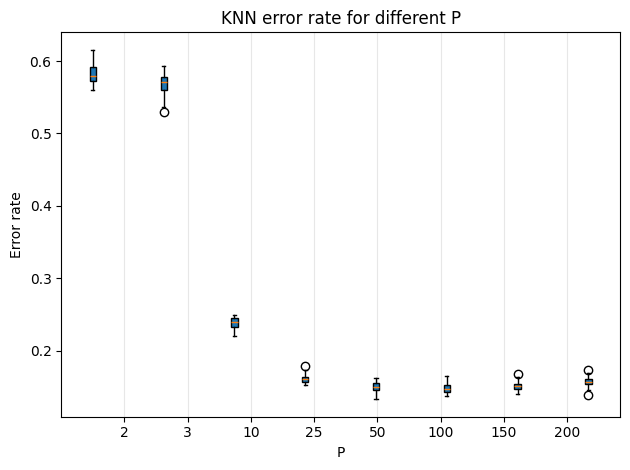

Best combination: P=50 with error 0.07822


In [160]:
results_val_linear_upd = np.array(results_val_linear)
results_test_linear_upd = np.array(results_test_linear)

print(results_val_linear_upd.shape)
print(len(results_val_linear_upd[(results_val_linear_upd[:,0] == 100) & (results_val_linear_upd[:,1] == 50)]))

visuale_error_for_one(P_vals, 'P', 'KNN', results_val_linear_upd, 0)

smallest_err, best_comb, errors_list = find_errors(P_vals, [1])
best_err = np.mean(results_test_upd[(results_test_upd[:, 0] == best_comb[0]) & (results_test_upd[:, 1] == best_comb[1]), 2])
print(f"Best combination: P={best_comb[0]} with error {best_err}")    


MAIN ONE: 

b is 0
b is 1
b is 2
b is 3
b is 4
b is 5
b is 6
b is 7
b is 8
b is 9
b is 10
b is 11
b is 12
b is 13
b is 14
b is 15
b is 16
b is 17
b is 18
b is 19
b is 20
b is 21
b is 22
b is 23
b is 24


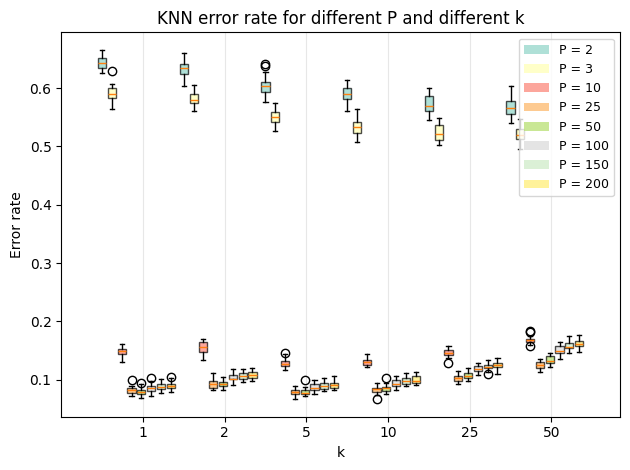

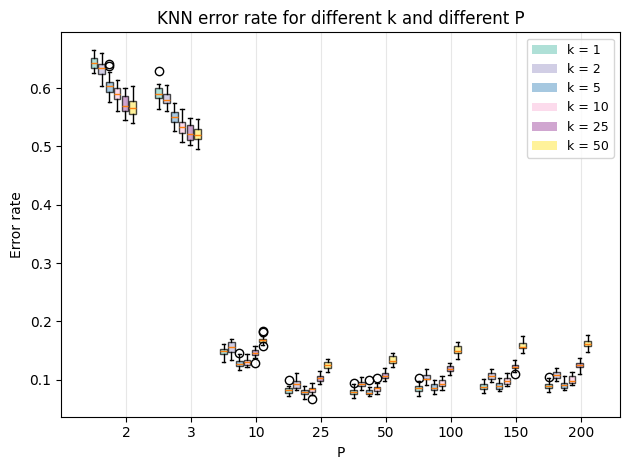

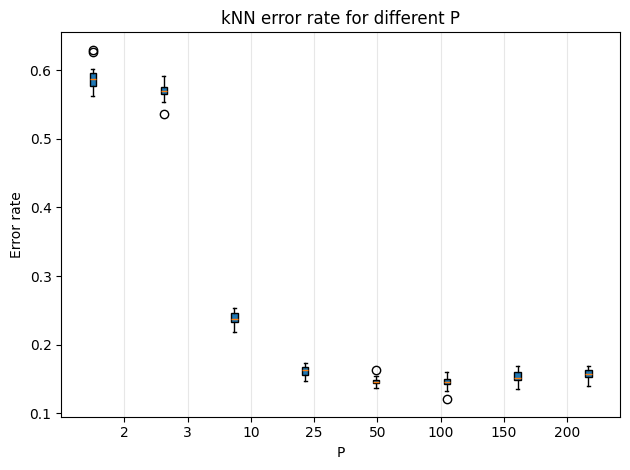

Best combination: P= 50 with error 25.073829999999997
Best combination: P=25, k=5 with error 0.07686666666666667


In [163]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
import os

k_vals = [1,2,5,10,25,50]
P_vals = [2,3,10, 25, 50, 100, 150, 200]
B = 25 # num of splits

results_val_knn = []
results_test_knn = []

results_val_linear = []
results_test_linear = []

for b in range(B):
    print(f"b is {b}")
    x_train, y_train, x_val, y_val, x_test, y_test, U_train, S_train, vt_train = compute_SVD(images, labels, images.shape[0])
    for pp, p_val in enumerate(P_vals):
        x_train_proj, x_test_proj, x_val_proj = calc_reduced_pattern(U_train, S_train, vt_train, p_val, x_test, x_val)

        lda = LinearDiscriminantAnalysis()
        lda.fit(x_train_proj, y_train)

        pred_val_lda = lda.predict(x_val_proj)
        pred_test_lda = lda.predict(x_test_proj)

        err_val_linear = np.sum(pred_val_lda != y_val)/len(y_val)
        err_test_linear = np.sum(pred_test_lda != y_test) / len(y_test)

        results_val_linear.append([p_val, err_val_linear])
        results_test_linear.append([p_val, err_test_linear])

        for kk, k_val in enumerate(k_vals):
            #Use skleans KNeighbours Classifier
            knn = KNeighborsClassifier(n_neighbors=k_val)
            knn.fit(x_train_proj, y_train)
            pred_val = knn.predict(x_val_proj)
            pred_test = knn.predict(x_test_proj)

            #Compute error rates
            err_val = np.sum(pred_val != y_val) / len(y_val)
            err_test = np.sum(pred_test != y_test) /len(y_test)

            results_val_knn.append([p_val, k_val, err_val])
            results_test_knn.append([p_val, k_val, err_test])

results_val_knn_upd = np.array(results_val_knn)
results_test_knn_upd = np.array(results_test_knn)

results_val_linear_upd = np.array(results_val_linear)
results_test_linear_upd = np.array(results_test_linear)


visuale_error(P_vals, k_vals, 'P', 'k', 'KNN', results_val_knn_upd, 0, 1)
visuale_error(k_vals, P_vals, 'k', 'P', 'KNN', results_val_knn_upd, 1, 0)

visuale_error_for_one(P_vals, 'P', 'kNN', results_val_linear_upd, 0)
smallest_err_linear, best_comb_linear, errors_list_linear = find_errors(P_vals, [1])
best_err_linear = np.mean(results_test_linear_upd[(results_test_linear_upd[:, 0] ==best_comb_linear[0])])
print(f"Best combination: P= {best_comb_linear[0]} with error {best_err_linear}")

smallest_err_knn, best_comb_knn, errors_list_knn = find_errors(P_vals, k_vals)
best_err_knn = np.mean(results_test_knn_upd[(results_test_knn_upd[:, 0] == best_comb_knn[0]) & (results_test_knn_upd[:, 1] == best_comb_knn[1]), 2])
print(f"Best combination: P={best_comb_knn[0]}, k={best_comb_knn[1]} with error {best_err_knn}")    



## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Class imbalance

For simplicity, restrict your data set to only 0s, 1s, and 2s. 

Create class imbalances in two different ways:
1. Keep the size of two classes and downsample the third.
2. Keep the size of one class and downsample the other two. 
You should explore at several levels of downsampling, from severe to mild. 

For each case, redo Part 1.

Compare class-specific accuracy and overall accuracy for the different classifiers. Do some models handle the downsampling better? In the most severe cases, can you see a reason to look at the class-specific accuracies and not just the overall accuracy?

### Theme 2 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? which methods struggle?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.*

### Theme 3 - Noise and dimension reduction

Add Gaussian noise to 10, 50, and 80 percent of the features (i.e. pixels). *Note, you should add the noise to both the training data and the test data.*

Choose 2 different dimension reduction methods and redo Part 1 with both, in addition to performing classification without any dimension reduction. (Consider how the variance of the noise and standardization of features may impact the outcome.)

How do the different dimension reduction methods compare? How do the different classifiers perform when the noise percentage is increased? Do any of them perform well without dimension reduction? Explain and discuss. 
